In [66]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from matplotlib.colors import ListedColormap, BoundaryNorm

import warnings
warnings.filterwarnings('ignore')

# Extent:

In [67]:
extent = [-120, -73, 18.5, 52.5]

# Mask for dataset to exclude HI, AK, PR, etc. 
lat_min, lat_max = 24.5, 49.5
lon_min, lon_max = -125.0, -66.9

# Projection info
proj= ccrs.LambertConformal()
PC = ccrs.PlateCarree()

In [68]:
ds_hail = xr.open_dataset('/home/z2034747/Research/Datasets/P_Per/pper_hail_1979_2023.nc')
ds_hail = ds_hail.assign_coords(lon= ds_hail.lon, lat= ds_hail.lat)
ds_hail = ds_hail['p_perfect_hail'].where((ds_hail.lon >= lon_min) & (ds_hail.lon <= lon_max) & (ds_hail.lat >= lat_min) & (ds_hail.lat <= lat_max), drop= True)

lats = ds_hail.lat.values
lons = ds_hail.lon.values

counts = len(ds_hail.time)

# Colorbars:


In [69]:
# Frequency of Exceedance:
foe_colors = ['#ffffb2','#fed976','#feb24c','#fd8d3c','#f03b20']
foe_15 = [1, 2, 3, 4, 5]
foe_5 = [1, 2, 4, 6, 8]

# Average:
mean_colors = ['#ffffb2','#fed976','#feb24c','#fd8d3c','#f03b20']
mean_levels = np.arange(0.3, 1.8, 0.3)

# PWAT: 
pwat_colors = ["#885c1e",
          "#a9834b",
          "#c1a779",
          "#d9cba7",
          "#f1f0d6",
          "#d6e6bd",
          "#bcdda4",
          "#a3d48d",
          "#89ca75",
          "#73c05d",
          "#50aa2d",
          "#1d4d06",
          "#6ea0ad",
          "#5a848d",
          "#44686d",
          "#2f4b4d",
          "#182b2b",
          "#666698",
          "#5a568d",
          "#4d4680",
          "#3f3575",
          "#7e7e00",
          "#9c9d00",
          "#bcbd00",
          "#dcdd00",
          "#fbfc00"]
pwat_levels = [i * 2.5 for i in range(27)]
pwat_colormap = ListedColormap(pwat_colors)

# Risk Colorbars:
risk_colors = [
    "#f4d71a",
    "#eb973d",
    "#bf4c78",
    "#5811a7",
    "#170f88",
    "#07d7f7"
]
risk_levels = [0.1, 0.5, 2.0, 5.0, 10.0, 15, 20]


# SOM Preferences:


In [70]:
prefs = {'filename': "/home/scratch/peldridge/combine_z500_pwat.nc", 
         'var1': 'gh', 'var2': 'pwat', 'wlon': 220, 'elon': 305, 'nlat': 55, 'slat': 20, 
         'som_config': {'x': 2, 'y': 3, 'sigma': 0.5, 'random_seed': 42},
         'som_train': {'num_iteration': 10000, 'random_order': True, 'verbose': True}}

length, width = prefs['som_config']['x'], prefs['som_config']['y']





# Plotting Code:

In [71]:
def mask_dataset(ds):
    return ds.where((ds.lon >= lon_min) & (ds.lon <= lon_max) & (ds.lat >= lat_min) & (ds.lat <= lat_max), drop= True)


def plot_glakes(ax):
    shpfilename = shpreader.natural_earth(resolution='10m', category='physical', name='lakes')
    reader = shpreader.Reader(shpfilename)
    
    great_lakes_names = ['Lake Superior', 'Lake Michigan', 'Lake Huron', 'Lake Erie', 'Lake Ontario', 'Lake St. Clair']
    great_lakes_geoms = [record.geometry for record in reader.records() if record.attributes.get('name') in great_lakes_names]

    ax.add_geometries(great_lakes_geoms, facecolor= cfeature.COLORS['water'], crs=ccrs.PlateCarree(), edgecolor='black')
    
def plot_pper_contour(pper_data, title, colors, levels, add_cbar= True): 
    
    # Calculate the Max:
    max_idx = np.nanargmax(pper_data)
    multi_index = np.unravel_index(max_idx, pper_data.shape)
    
    # Set up axes and decorations:
    ax = plt.subplot(1, 1, 1, projection= proj)
    ax.set_extent(extent)
    ax.add_feature(cfeature.STATES)
    ax.coastlines()
    ax.add_feature(cfeature.OCEAN)
    ax.add_feature(cfeature.LAND, facecolor= 'grey')
    plot_glakes(ax)
    
    # Plotting Data:
    contourf = ax.contourf(lons, lats, pper_data, colors= colors, levels= levels, extend= 'max', transform= PC)
    contour = ax.contour(lons, lats, pper_data, colors= 'k', linewidths= 0.5, levels= levels, transform= PC)
    
    # Plotting max point:
    ax.text(0.03, 0.05, f'MAX (*): {pper_data.max().values:.1f}%', transform= ax.transAxes, bbox= dict(facecolor= 'w', edgecolor= 'k', boxstyle= 'round'))
    ax.plot(pper_data['lon'].values[multi_index], pper_data['lat'].values[multi_index], markersize= 5, marker= '*', color= 'k', transform= ccrs.PlateCarree())
    
    # Colorbar:
    if add_cbar:
        cax = ax.inset_axes([0.0, -0.1, 0.65, 0.05])
        plt.colorbar(contourf, cax, orientation= 'horizontal', ticks= levels)

    # Finally, the title:
    ax.set_title(title, fontweight= 'bold')
    
    return ax


def plot_pper_stamps(pper_list_data, colors, levels):
        
    # Set up axes:
    fig, axes = plt.subplots(length, width, subplot_kw= {'projection': proj}, constrainted_layout= False)
    axes = np.atleast_2d(axes)
    
    
    
    
    
    return ax


## Test Plots:

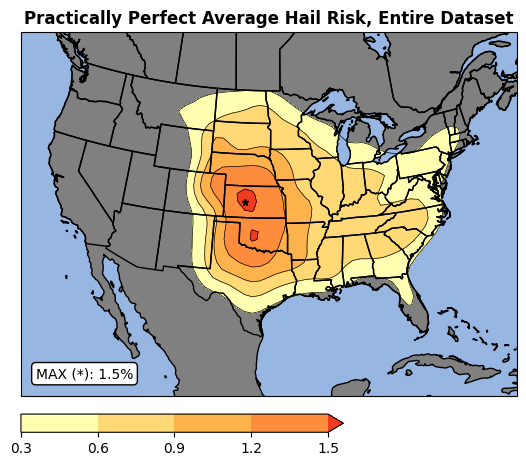

In [40]:
hail_mean = ds_hail.mean(dim= 'time')
plot_pper_contour(hail_mean, 'Practically Perfect Average Hail Risk, Entire Dataset', mean_colors, mean_levels)
plt.show()

<GeoAxes: title={'center': 'PPER Hail Risk Std. Deviation, Entire Dataset'}>

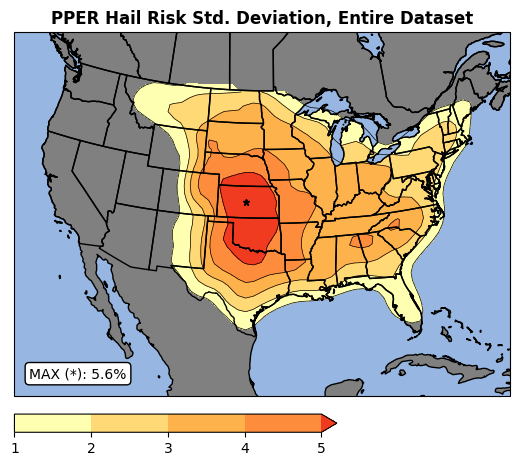

In [15]:
hail_std = ds_hail.std(dim= 'time')
plot_pper_contour(hail_std, 'PPER Hail Risk Std. Deviation, Entire Dataset', foe_colors, np.arange(1, 6, 1))

In [82]:
threshold= 15
arr_15 = ds_hail.where(ds_hail >= threshold) * 0 + 1
sum_15 = arr_15.sum(axis= 0)
freq_15 = sum_15 / counts * 100

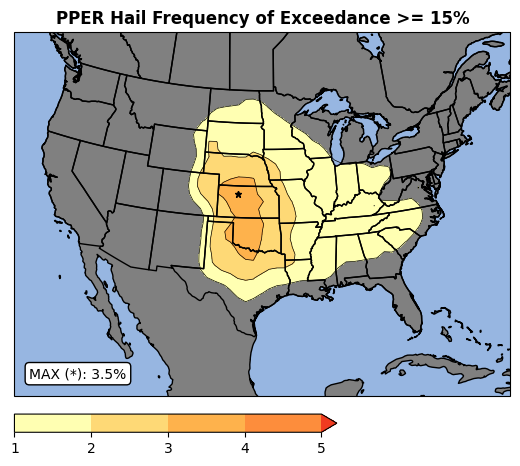

In [83]:
plot_pper_contour(freq_15, 'PPER Hail Frequency of Exceedance >= 15%', foe_colors, foe_15)
plt.savefig('./Figures/PPER_FOE_15.png', dpi= 300, bbox_inches= 'tight')
plt.show()

In [84]:
threshold= 5
arr_5 = ds_hail.where(ds_hail >= threshold) * 0 + 1
sum_5 = arr_5.sum(axis= 0)
freq_5 = sum_5 / counts * 100

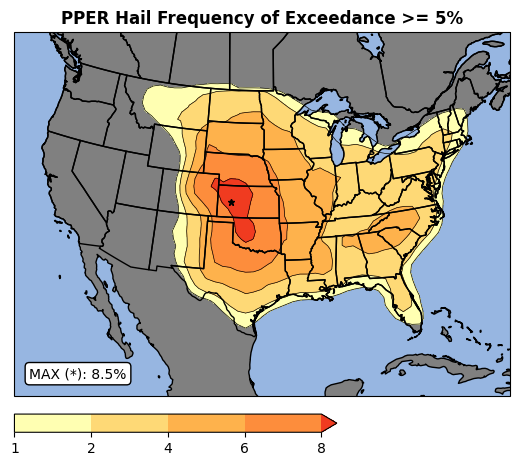

In [85]:
plot_pper_contour(freq_5, f'PPER Hail Frequency of Exceedance >= {threshold}%', foe_colors, foe_5)
plt.savefig('./Figures/PPER_FOE_5.png', dpi= 300, bbox_inches= 'tight')

In [ ]:
# def big_plot(pper_data, x, y, colrsa,,,, .... ):
    # fig = plt.figure()
    # ax = plt.subplot(x, y, projection= xxx)
    # for _ in _:
        # if beginning_of_row:
            # plot_pper_contour(afsdfsdaf)
        # else: 
            # plot_pper_contour(asdlfkja;lfd, add_cbar= False)

In [60]:
ds = xr.open_dataset('/home/scratch/peldridge/pper_climo/pper_hail_climatology.nc')

In [64]:
plot_pper_contour(mask_dataset(ds['mean']), 'mean', mean_colors, mean_levels)

AttributeError: 'DataArray' object has no attribute 'lon'

In [65]:
ds

<xarray.Dataset> Size: 326kB
Dimensions:  (x: 93, y: 65, time: 16436)
Coordinates:
  * x        (x) float64 744B 0.0 1.0 2.0 3.0 4.0 ... 88.0 89.0 90.0 91.0 92.0
  * y        (y) float64 520B 0.0 1.0 2.0 3.0 4.0 ... 60.0 61.0 62.0 63.0 64.0
  * time     (time) datetime64[ns] 131kB 1979-01-01T12:00:00 ... 2023-12-31T1...
Data variables:
    mean     (y, x) float64 48kB 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    std      (y, x) float64 48kB ...
    freq_15  (y, x) float64 48kB ...
    freq_5   (y, x) float64 48kB ...
Attributes:
    title:         Practically Perfect Hail Hindcasts
    grid:          80-km NCEP 211
    sigma:         1.5
    author:        Dr. Victor Gensini
    author_email:  vgensini@niu.edu
    citation:      https://doi.org/10.1175/BAMS-D-19-0321.1